# Resources Open Doors, but Capabilities Pave the Way

## Public analysis and main figures

This notebook follows a compact public-reproducibility format: it reads only
non-identifying aggregate data and saved statistical outputs from `Data/`,
checks the released matching and diagnostic results, and recreates the final
reported Figures 2--4. It does not construct linked mentor--mentee records,
infer identities, or generate manuscript documents.


In [1]:
from pathlib import Path

from IPython.display import Image, display
import pandas as pd

ROOT = Path.cwd()
DATA = ROOT / "Data"
FIGURE = ROOT / "Figure"
if not DATA.exists():
    raise FileNotFoundError("Run this notebook from the Data_Code_Public directory.")
FIGURE.mkdir(exist_ok=True)


## 1. Released-data inventory


In [2]:
inventory = []
for path in sorted(DATA.glob("*.csv")):
    frame = pd.read_csv(path)
    inventory.append({"file": path.name, "rows": len(frame), "columns": len(frame.columns)})
inventory = pd.DataFrame(inventory)
inventory


,file,rows,columns
0,group_distribution_summary.csv,16,11
1,kde_density_curves.csv,1928,6
2,main_table3_network_policy_audit.csv,3,7
3,main_table3_spearman.csv,8,4
4,main_table3_spearman_audit.csv,24,5
5,network_size_rebuild_audit.csv,14,9
6,psm_balance.csv,238,20
7,psm_effects.csv,106,23
8,psm_run_summary.csv,61,14
9,regression_coefficients.csv,528,13


## 2. Main Table 3

The displayed table is read directly from the released aggregate file. The
audit file contains the underlying sample sizes, Spearman correlations, and
p-values.


In [3]:
table3 = pd.read_csv(DATA / "main_table3_spearman.csv")
table3_audit = pd.read_csv(DATA / "main_table3_spearman_audit.csv")
display(table3)
display(table3_audit)


,Variable,5-year,10-year,20-year
0,Topic_Continuity,+0.230***,+0.161***,+0.075***
1,Net_Consistency,+0.311***,+0.290***,+0.263***
2,Direct_Percent,-0.101***,-0.072***,-0.008
3,PeerCount_log,-0.059***,-0.060***,-0.057***
4,h_index,+0.174***,+0.168***,+0.162***
5,AvgPaperPerYear_Mentored,+0.813***,+0.818***,+0.809***
6,NetworkSize_Mentored,+0.565***,+0.571***,+0.569***
7,AvgTopPubPerYear_Mentored,+0.822***,+0.818***,+0.794***


,window,variable,n,spearman_rho,p_value
0,5,Topic_Continuity,59583,0.229668,0.000000e+00
1,5,Net_Consistency,60464,0.310743,0.000000e+00
2,5,Direct_Percent,60464,-0.101166,2.772654e-137
3,5,PeerCount_log,97140,-0.059230,3.207944e-76
4,5,h_index,83430,0.173633,0.000000e+00
5,5,AvgPaperPerYear_Mentored,97140,0.812614,0.000000e+00
6,5,NetworkSize_Mentored,69289,0.565083,0.000000e+00
7,5,AvgTopPubPerYear_Mentored,97140,0.822441,0.000000e+00
8,10,Topic_Continuity,45684,0.160859,2.034427e-262
9,10,Net_Consistency,44816,0.289757,0.000000e+00


## 3. Matching-balance verification

Every released propensity-score-matching run must have a maximum absolute
post-matching standardized mean difference below .10.


In [4]:
psm_summary = pd.read_csv(DATA / "psm_run_summary.csv")
psm_summary["balance_pass"] = psm_summary["balance_pass"].astype(str).str.lower().eq("true")
assert psm_summary["balance_pass"].all()
assert (psm_summary["max_abs_smd_after"] < 0.10).all()
psm_summary.groupby(["family", "analysis"], as_index=False).agg(
    runs=("balance_pass", "size"),
    largest_postmatch_smd=("max_abs_smd_after", "max"),
    all_pass=("balance_pass", "all"),
)


,family,analysis,runs,largest_postmatch_smd,all_pass
0,conventional,PSM1,9,0.068488,True
1,conventional,PSM2:direct_percent,9,0.017644,True
2,conventional,PSM2:log_PeerCount,9,0.008813,True
3,conventional,PSM2:network_consistency,9,0.019025,True
4,conventional,PSM2:topic_continuity,9,0.017970,True
5,landmark,PSM1,2,0.052822,True
6,landmark,PSM2:direct_percent,2,0.017685,True
7,landmark,PSM2:log_PeerCount,2,0.008216,True
8,landmark,PSM2:network_consistency,2,0.014014,True
9,landmark,PSM2:topic_continuity,2,0.015527,True


## 4. Final figure functions

The following cell contains the final aggregate plotting logic. All estimates
are read from the released CSV files rather than entered manually.


In [5]:
from __future__ import annotations

import argparse

from pathlib import Path

import matplotlib

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from matplotlib.lines import Line2D

COLORS = {
    "topic_continuity": "#D84B5B",
    "network_consistency": "#2B82A4",
    "direct_percent": "#737E84",
    "log_PeerCount": "#8756B3",
}

LABELS = {
    "topic_continuity": "TC",
    "network_consistency": "NC",
    "direct_percent": "DP",
    "log_PeerCount": "PC",
}

LEGEND_LABELS = {
    "topic_continuity": "Topic_Continuity",
    "network_consistency": "Net_Consistency",
    "direct_percent": "Direct_Percent",
    "log_PeerCount": "PeerCount_log",
}

GROUPS = ["G1a", "G1b", "G2a", "G2b"]

GROUP_COLORS = {
    "G1a": "#A61C00",
    "G1b": "#F49D83",
    "G2a": "#1F4E79",
    "G2b": "#6FA8DC",
}

GROUP_LABELS = {
    "G1a": "G1a  Improved after graduation",
    "G1b": "G1b  Late bloomer",
    "G2a": "G2a  Declined after graduation",
    "G2b": "G2b  No citation-elite output in either period",
}

def configure() -> None:
    plt.rcParams.update(
        {
            "font.family": "Arial",
            "font.size": 12,
            "axes.titlesize": 14,
            "axes.titleweight": "bold",
            "axes.labelsize": 12,
            "xtick.labelsize": 11,
            "ytick.labelsize": 11,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "pdf.fonttype": 42,
        }
    )

def save(fig: plt.Figure, output: Path) -> None:
    output.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output.with_suffix(".png"), dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(output.with_suffix(".pdf"), bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(output.with_suffix(".png"))
    print(output.with_suffix(".pdf"))

def make_group_figure(data_dir: Path, output: Path) -> None:
    bars = pd.read_csv(data_dir / "figure2_panel_a_standardized_means.csv")
    density = pd.read_csv(data_dir / "kde_density_curves.csv")
    variables = [
        ("Continuity", "Topic continuity\n(TC)"),
        ("Net_Consistency", "Network consistency\n(NC)"),
        ("Direct_rel", "Direct mentor collaboration\n(DP)"),
        ("PeerCount_rel", "Peer environment\n(PC)"),
    ]

    fig = plt.figure(figsize=(13.8, 8.6))
    grid = fig.add_gridspec(2, 2, height_ratios=[1.08, 1], hspace=0.36, wspace=0.22)
    ax_bar = fig.add_subplot(grid[0, :])
    x = np.arange(len(variables))
    width = 0.18
    offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width]

    for group, offset in zip(GROUPS, offsets):
        group_rows = bars[bars["Group"].eq(group)].set_index("Variable")
        means = [float(group_rows.loc[variable, "MeanZ"]) for variable, _ in variables]
        errors = [float(group_rows.loc[variable, "CI95"]) for variable, _ in variables]
        ax_bar.bar(
            x + offset,
            means,
            width=width * 0.9,
            yerr=errors,
            capsize=2.2,
            color=GROUP_COLORS[group],
            edgecolor="white",
            linewidth=0.5,
            label=GROUP_LABELS[group],
        )
    ax_bar.axhline(0, color="#555555", linewidth=1)
    ax_bar.grid(axis="y", linestyle="--", alpha=0.28)
    ax_bar.set_xticks(x, [label for _, label in variables])
    ax_bar.set_ylabel("Standardized group mean (z-score; 95% CI)")
    ax_bar.legend(ncol=4, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.18), fontsize=11)
    ax_bar.text(-0.05, 1.06, "A", transform=ax_bar.transAxes, fontweight="bold", fontsize=15)

    for ax, panel, letter, xlabel in (
        (fig.add_subplot(grid[1, 0]), "network", "B", "log10(Network size + 1)"),
        (fig.add_subplot(grid[1, 1]), "hindex", "C", "log10(h-index + 1)"),
    ):
        curves = density[(density["Panel"].eq(panel)) & (density["Kind"].eq("curve"))]
        medians = density[(density["Panel"].eq(panel)) & (density["Kind"].eq("median"))]
        for group in GROUPS:
            curve = curves[curves["Group"].eq(group)].sort_values("Order")
            ax.plot(curve["X"], curve["Y"], color=GROUP_COLORS[group], linewidth=1.8)
            median = medians[medians["Group"].eq(group)]
            if not median.empty:
                ax.axvline(float(median.iloc[0]["X"]), color=GROUP_COLORS[group], linestyle="--", linewidth=1)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Density")
        ax.grid(alpha=0.18)
        ax.text(-0.10, 1.04, letter, transform=ax.transAxes, fontweight="bold", fontsize=15)
    save(fig, output)

def panel_rows(ax: plt.Axes, rows: pd.DataFrame, title: str, xlabel: str) -> None:
    rows = rows.reset_index(drop=True)
    y = np.arange(len(rows))[::-1]
    minimum = min(float(rows["estimate"].min()), 0.0)
    maximum = max(float(rows["estimate"].max()), 0.0)
    spread = max(maximum - minimum, 0.1)
    padding = 0.16 * spread
    ax.set_xlim(minimum - padding, maximum + padding)
    ax.axvline(0, color="#888888", linewidth=0.9)
    ax.grid(axis="x", alpha=0.22)
    for position, (_, row) in zip(y, rows.iterrows()):
        variable = row["variable"]
        value = float(row["estimate"])
        p_value = row.get("clustered_p_value", row.get("p_value", np.nan))
        significant = pd.notna(p_value) and float(p_value) < 0.05
        ax.hlines(position, 0, value, color=COLORS[variable], linewidth=2.5)
        ax.scatter(
            value,
            position,
            facecolor=COLORS[variable] if significant else "white",
            edgecolor=COLORS[variable],
            linewidth=1.8,
            s=48,
            zorder=3,
        )
        if "%" in xlabel or "percentage" in xlabel.lower():
            label = f"{value:+.1f}%"
        else:
            label = f"{value:+.2f}"
        offset = 0.025 * spread
        ax.text(
            value + (offset if value >= 0 else -offset),
            position,
            label,
            ha="left" if value >= 0 else "right",
            va="center",
            fontsize=10,
            color="#333333",
        )
    ax.set_yticks(y, rows["row_label"])
    ax.set_title(title)
    ax.set_xlabel(xlabel)

def grouped_panel(
    ax: plt.Axes,
    rows: pd.DataFrame,
    *,
    block_order: list[str],
    variable_order: list[str],
    title: str,
    xlabel: str,
    letter: str,
    label_mode: str = "number",
) -> None:
    """Draw a compact window-faceted lollipop panel."""

    data = rows.copy()
    order = {name: index for index, name in enumerate(variable_order)}
    data["variable_order"] = data["variable"].map(order)
    data = data.sort_values(["block_order", "variable_order"])
    minimum = min(float(data["estimate"].min()), 0.0)
    maximum = max(float(data["estimate"].max()), 0.0)
    spread = max(maximum - minimum, 0.1)
    padding = 0.17 * spread
    xmin = minimum - padding
    xmax = maximum + padding
    ax.set_xlim(xmin, xmax)
    ax.axvline(0, color="#888888", linewidth=0.9, zorder=2)
    ax.grid(axis="x", color="#D7DADF", linewidth=0.7, alpha=0.7, zorder=1)

    tick_positions: list[float] = []
    tick_labels: list[str] = []
    cursor = 0.0
    for block_index, block_label in enumerate(block_order):
        block = data[data["block_label"].eq(block_label)]
        if block.empty:
            continue
        label_y = cursor + 0.18
        first_y = cursor + 0.82
        last_y = first_y + len(block) - 1
        ax.axhspan(
            cursor - 0.08,
            last_y + 0.48,
            color="#F1F2F4" if block_index % 2 == 0 else "#F7F7F7",
            zorder=0,
        )
        ax.text(
            xmin + 0.02 * (xmax - xmin),
            label_y,
            block_label,
            ha="left",
            va="center",
            fontsize=9.5,
            fontweight="bold",
            color="#4B4B4B",
        )
        for row_index, (_, row) in enumerate(block.iterrows()):
            y = first_y + row_index
            value = float(row["estimate"])
            p_value = row.get("clustered_p_value", row.get("p_value", np.nan))
            significant = pd.notna(p_value) and float(p_value) < 0.05
            variable = str(row["variable"])
            color = COLORS[variable]
            ax.hlines(y, 0, value, color=color, linewidth=2.35, zorder=3)
            ax.scatter(
                value,
                y,
                s=54,
                facecolor=color if significant else "white",
                edgecolor=color,
                linewidth=1.8,
                zorder=4,
            )
            if label_mode == "percent":
                value_label = f"{value:+.1f}%"
            elif label_mode == "pp":
                value_label = f"{value:+.2f} pp"
            else:
                value_label = f"{value:+.2f}"
            offset = 0.018 * spread
            ax.text(
                value + (offset if value >= 0 else -offset),
                y,
                value_label,
                ha="left" if value >= 0 else "right",
                va="center",
                fontsize=9.2,
                color="#3F3F3F",
                zorder=5,
            )
            tick_positions.append(y)
            tick_labels.append(LABELS[variable])
        cursor = last_y + 0.92

    ax.set_ylim(cursor - 0.38, -0.18)
    ax.set_yticks(tick_positions, tick_labels)
    ax.set_title(title, fontsize=12.5, pad=8)
    ax.set_xlabel(xlabel, fontsize=10.5)
    ax.tick_params(axis="both", labelsize=9.5)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#B8B8B8")
        spine.set_linewidth(0.8)
    ax.text(
        -0.10,
        1.04,
        letter,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="bottom",
    )

def add_variable_legend(fig: plt.Figure, variables: list[str]) -> None:
    handles = [
        Line2D(
            [0],
            [0],
            color=COLORS[variable],
            marker="o",
            markersize=6,
            linewidth=2.1,
            label=LEGEND_LABELS[variable],
        )
        for variable in variables
    ]
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.995),
        ncol=len(variables),
        frameon=False,
        fontsize=10.5,
        handlelength=2.2,
        columnspacing=2.0,
    )

def resource_frames(effects: pd.DataFrame, coefficients: pd.DataFrame) -> tuple[pd.DataFrame, ...]:
    frames: list[pd.DataFrame] = []
    for analysis in ("PSM0", "PSM1"):
        family = "mentorship_period" if analysis == "PSM0" else "conventional"
        block = effects[
            effects["family"].eq(family)
            & effects["gap"].eq(3)
            & effects["analysis"].eq(analysis)
            & effects["outcome"].isin(["direct_percent", "log_PeerCount"])
        ].copy()
        block["estimate"] = block["outcome_smd"]
        block["variable"] = block["outcome"]
        if analysis == "PSM0":
            block["window"] = 0
            block["row_label"] = "PSM0  " + block["variable"].map(LABELS)
            overall_psm1 = effects[
                effects["family"].eq("overall")
                & effects["gap"].eq(3)
                & effects["analysis"].eq("PSM1")
                & effects["outcome"].isin(["direct_percent", "log_PeerCount"])
            ].copy()
            overall_psm1["estimate"] = overall_psm1["outcome_smd"]
            overall_psm1["variable"] = overall_psm1["outcome"]
            overall_psm1["window"] = 1
            overall_psm1["row_label"] = (
                "PSM1 overall  " + overall_psm1["variable"].map(LABELS)
            )
            block = pd.concat([block, overall_psm1], ignore_index=True)
        else:
            block["window"] = block["horizon"].str.extract(r"(\d+)").astype(int)
            block["row_label"] = block.apply(lambda r: f"{r['window']}-year  {LABELS[r['variable']]}", axis=1)
        frames.append(block.sort_values(["window", "variable"]))

    for model in ("LPM-any-cluster-mentee", "Gamma-positive-cluster-mentee"):
        block = coefficients[
            coefficients["family"].eq("conventional")
            & coefficients["gap"].eq(3)
            & coefficients["model"].eq(model)
            & coefficients["term"].isin(["direct_percent", "log_PeerCount"])
        ].copy()
        block["variable"] = block["term"]
        block["window"] = block["horizon"].str.extract(r"(\d+)").astype(int)
        if model.startswith("LPM"):
            block["estimate"] = block["coefficient"] * 0.1 * 100
        else:
            block["estimate"] = 100 * (np.exp(0.1 * block["coefficient"]) - 1)
        block["row_label"] = block.apply(lambda r: f"{r['window']}-year  {LABELS[r['variable']]}", axis=1)
        frames.append(block.sort_values(["window", "variable"]))
    return tuple(frames)

def make_resource_figure(effects: pd.DataFrame, coefficients: pd.DataFrame, output: Path) -> None:
    psm0, psm1, part1, part2 = resource_frames(effects, coefficients)
    psm0["block_label"] = np.where(
        psm0["analysis"].eq("PSM0"), "PSM0: mentorship period", "PSM1: overall career"
    )
    psm0["block_order"] = psm0["block_label"].map(
        {"PSM0: mentorship period": 0, "PSM1: overall career": 1}
    )
    window_labels = {"L5": "Short term", "L10": "Medium term", "L20": "Long term"}
    for block in (psm1, part1, part2):
        block["block_label"] = block["horizon"].map(window_labels)
        block["block_order"] = block["horizon"].map({"L5": 0, "L10": 1, "L20": 2})

    fig, axes = plt.subplots(2, 2, figsize=(13.0, 9.0))
    variables = ["direct_percent", "log_PeerCount"]
    grouped_panel(
        axes[0, 0], psm0,
        block_order=["PSM0: mentorship period", "PSM1: overall career"],
        variable_order=variables,
        title="Overall matched comparison",
        xlabel="Outcome SMD after matching",
        letter="A",
    )
    grouped_panel(
        axes[0, 1], psm1,
        block_order=["Short term", "Medium term", "Long term"],
        variable_order=variables,
        title="PSM1 by career window",
        xlabel="Outcome SMD after matching",
        letter="B",
    )
    grouped_panel(
        axes[1, 0], part1,
        block_order=["Short term", "Medium term", "Long term"],
        variable_order=variables,
        title="Two-part model: publication probability",
        xlabel="Probability change (percentage points)",
        letter="C",
        label_mode="pp",
    )
    grouped_panel(
        axes[1, 1], part2,
        block_order=["Short term", "Medium term", "Long term"],
        variable_order=variables,
        title="Two-part model: positive-output intensity",
        xlabel="Expected intensity change (%)",
        letter="D",
        label_mode="percent",
    )
    add_variable_legend(fig, variables)
    fig.tight_layout(rect=(0.02, 0.01, 0.99, 0.95), h_pad=2.5, w_pad=2.8)
    save(fig, output)

def make_landmark_figure(effects: pd.DataFrame, coefficients: pd.DataFrame, output: Path) -> None:
    specs: list[tuple[pd.DataFrame, str, str]] = []
    landmark_psm1 = effects[
        effects["family"].eq("landmark") & effects["analysis"].eq("PSM1")
    ].copy()
    landmark_psm1["estimate"] = landmark_psm1["outcome_smd"]
    landmark_psm1["variable"] = landmark_psm1["outcome"]
    specs.append((landmark_psm1, "A  Landmark PSM1", "Outcome SMD after matching"))

    landmark_psm2 = effects[
        effects["family"].eq("landmark") & effects["analysis"].str.startswith("PSM2:")
    ].copy()
    landmark_psm2["estimate"] = landmark_psm2["mean_difference"]
    landmark_psm2["variable"] = landmark_psm2["analysis"].str.split(":").str[1]
    specs.append((landmark_psm2, "B  Landmark PSM2", "Matched mean difference (publications/year)"))

    landmark_ppml = coefficients[
        coefficients["family"].eq("landmark")
        & coefficients["model"].eq("PPML-cluster-mentee")
        & coefficients["term"].isin(LABELS)
    ].copy()
    landmark_ppml["estimate"] = 100 * (np.exp(0.1 * landmark_ppml["coefficient"]) - 1)
    landmark_ppml["variable"] = landmark_ppml["term"]
    specs.append((landmark_ppml, "C  Landmark PPML", "Expected output-rate change (%)"))

    conventional_psm2 = effects[
        effects["family"].eq("conventional")
        & effects["gap"].eq(3)
        & effects["analysis"].str.startswith("PSM2:")
    ].copy()
    conventional_psm2["estimate"] = conventional_psm2["mean_difference"]
    conventional_psm2["variable"] = conventional_psm2["analysis"].str.split(":").str[1]
    specs.append((conventional_psm2, "D  Conventional PSM2", "Matched mean difference (publications/year)"))

    prepared: list[tuple[pd.DataFrame, str, str, str]] = []
    for block, title, xlabel in specs:
        if block["family"].eq("landmark").all():
            window_map = {
                "early1_3_to_later4_10": "Years 4-10",
                "early1_3_to_later6_20": "Years 6-20",
            }
            block["block_label"] = block["horizon"].map(window_map)
            block["block_order"] = block["horizon"].map(
                {
                    "early1_3_to_later4_10": 1,
                    "early1_3_to_later6_20": 2,
                }
            )
        else:
            block["block_label"] = block["horizon"].map(
                {"L5": "Short term", "L10": "Medium term", "L20": "Long term"}
            )
            block["block_order"] = block["horizon"].map({"L5": 1, "L10": 2, "L20": 3})
        mode = "percent" if "rate change" in xlabel else "number"
        prepared.append((block, title.split("  ", 1)[-1], xlabel, mode))

    fig, axes = plt.subplots(2, 2, figsize=(13.0, 9.0))
    variables = ["topic_continuity", "network_consistency", "direct_percent", "log_PeerCount"]
    letters = ["A", "B", "C", "D"]
    for ax, (block, title, xlabel, mode), letter in zip(axes.ravel(), prepared, letters):
        block_order = (
            ["Years 4-10", "Years 6-20"]
            if block["family"].eq("landmark").all()
            else ["Short term", "Medium term", "Long term"]
        )
        grouped_panel(
            ax,
            block,
            block_order=block_order,
            variable_order=variables,
            title=title,
            xlabel=xlabel,
            letter=letter,
            label_mode=mode,
        )
    add_variable_legend(fig, variables)
    fig.tight_layout(rect=(0.02, 0.01, 0.99, 0.95), h_pad=2.5, w_pad=2.8)
    save(fig, output)


In [6]:
configure()
effects = pd.read_csv(DATA / "psm_effects.csv")
coefficients = pd.read_csv(DATA / "regression_coefficients.csv")

make_group_figure(DATA, FIGURE / "figure2_group_profiles")
make_resource_figure(effects, coefficients, FIGURE / "figure3_resource_results")
make_landmark_figure(effects, coefficients, FIGURE / "figure4_landmark_results")


D:\1他爹的谁爱学谁学\sos\mentorship\Data_Code_Public\Figure\figure2_group_profiles.png
D:\1他爹的谁爱学谁学\sos\mentorship\Data_Code_Public\Figure\figure2_group_profiles.pdf


D:\1他爹的谁爱学谁学\sos\mentorship\Data_Code_Public\Figure\figure3_resource_results.png
D:\1他爹的谁爱学谁学\sos\mentorship\Data_Code_Public\Figure\figure3_resource_results.pdf


D:\1他爹的谁爱学谁学\sos\mentorship\Data_Code_Public\Figure\figure4_landmark_results.png
D:\1他爹的谁爱学谁学\sos\mentorship\Data_Code_Public\Figure\figure4_landmark_results.pdf


## 5. Generated figure previews


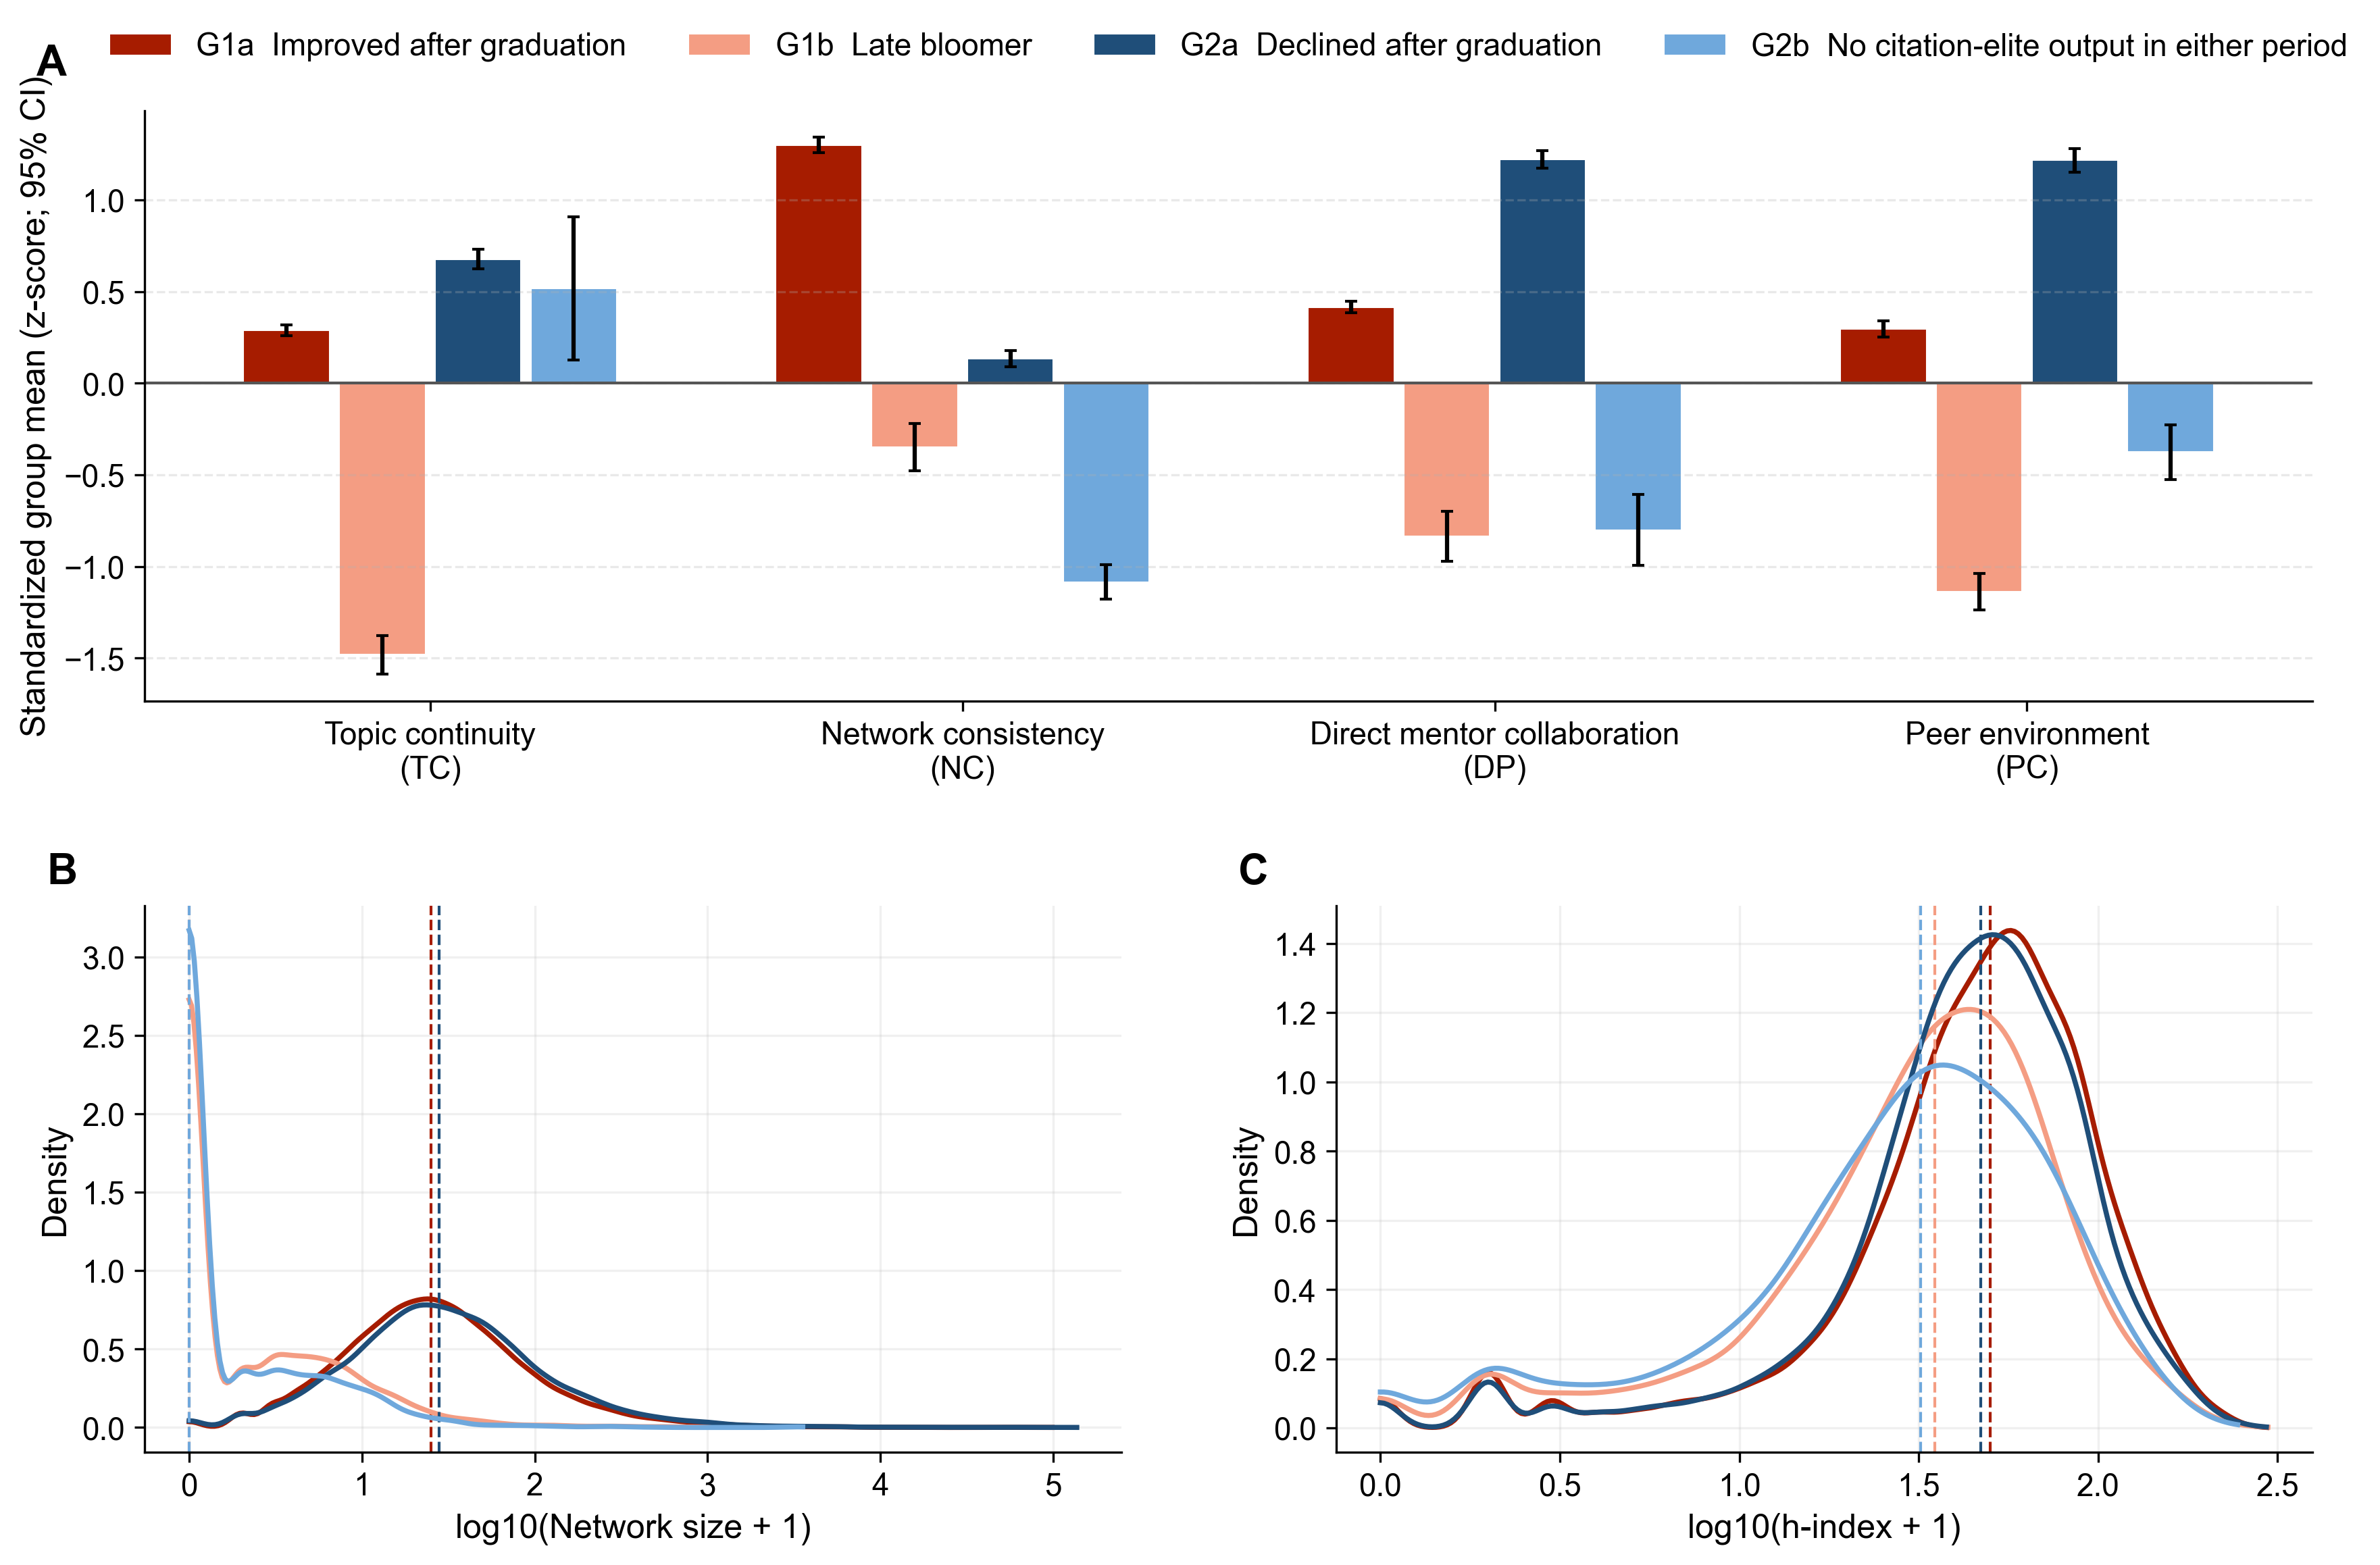

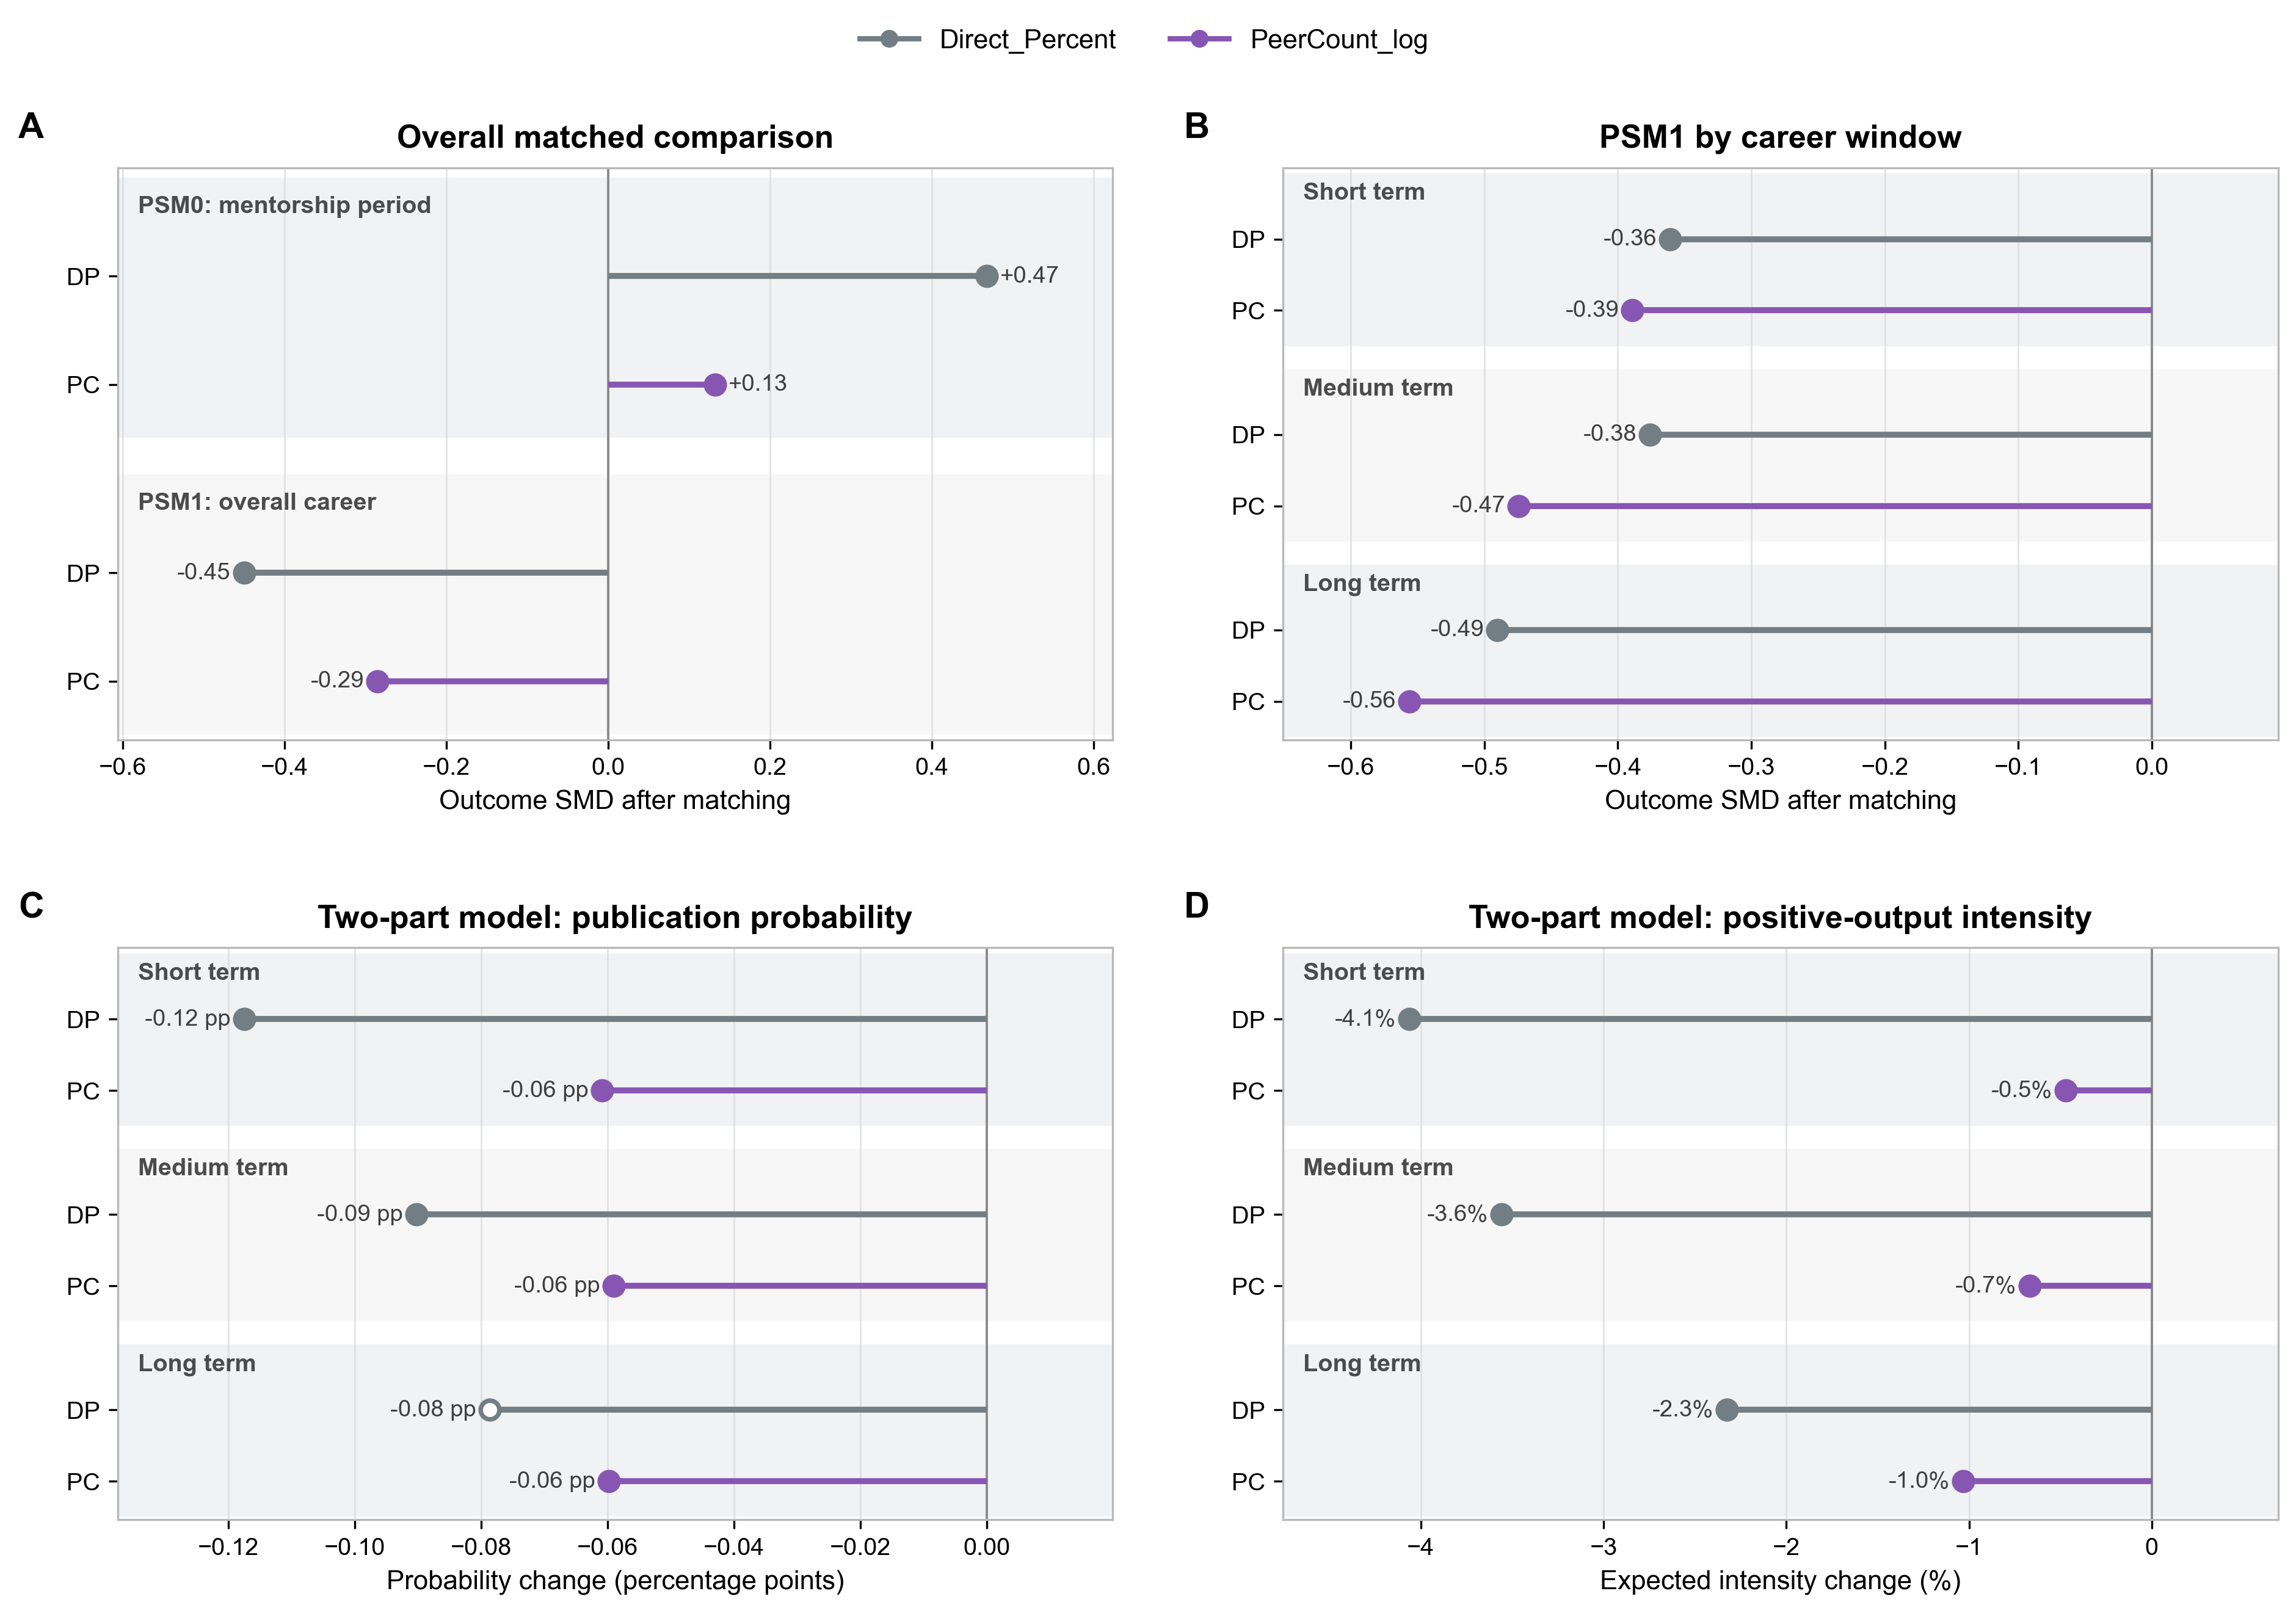

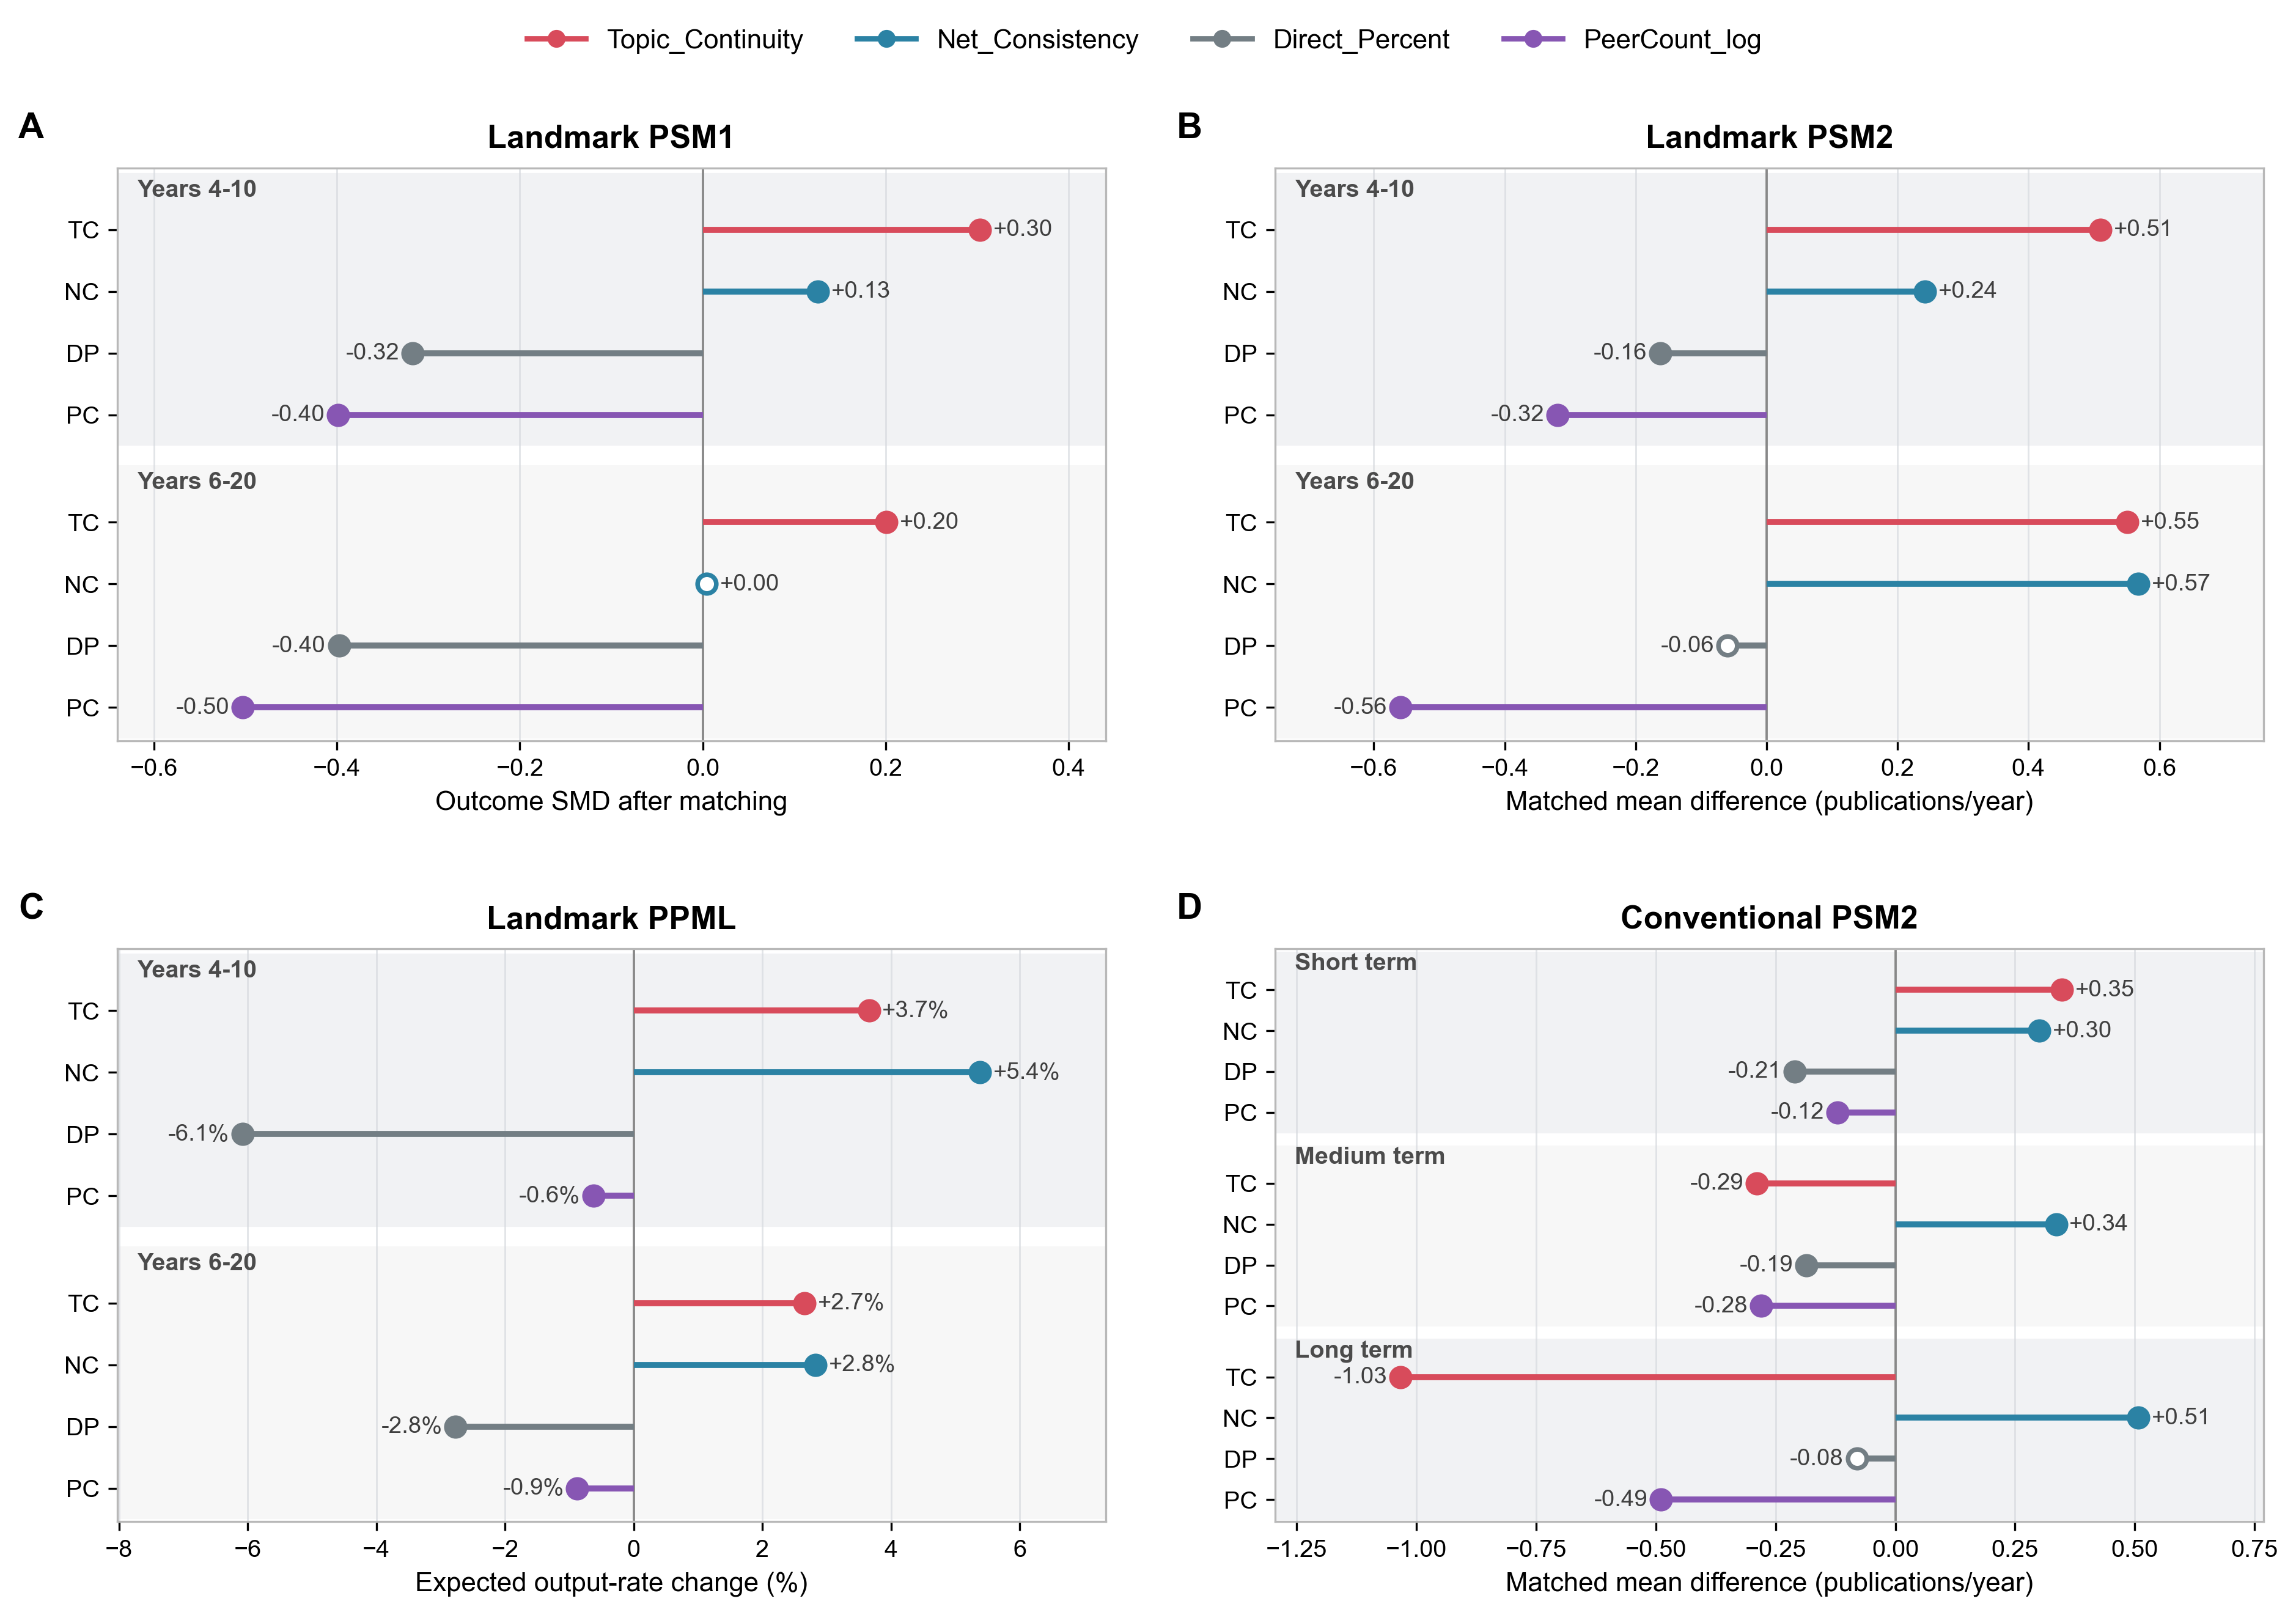

In [7]:
for name in [
    "figure2_group_profiles.png",
    "figure3_resource_results.png",
    "figure4_landmark_results.png",
]:
    display(Image(filename=str(FIGURE / name)))


## 6. Diagnostics and sample flow


In [8]:
diagnostics = pd.read_csv(DATA / "regression_diagnostics.csv")
sample_flow = pd.read_csv(DATA / "sample_flow.csv")
vif = pd.read_csv(DATA / "vif_diagnostics.csv")

display(diagnostics.groupby(["family", "model"], as_index=False).agg(
    specifications=("model", "size"),
    minimum_n=("nobs", "min"),
    maximum_n=("nobs", "max"),
))
display(sample_flow)
display(vif.groupby("variable", as_index=False)["vif"].agg(["min", "median", "max"]))


,family,model,specifications,minimum_n,maximum_n
0,conventional,Gamma-positive,9,19988,55221
1,conventional,LPM-any,9,20568,58501
2,conventional,OLS,9,20568,58501
3,conventional,PPML,9,20568,58501
4,landmark,Gamma-positive,2,18513,37896
5,landmark,LPM-any,2,19319,40769
6,landmark,OLS,2,19319,40769
7,landmark,PPML,2,19319,40769


,family,gap,horizon,raw_rows,complete_regression_rows,complete_case_retention,unique_mentees,unique_mentors,raw_zero_count_rows,raw_zero_count_share,raw_count_mean,zero_count_rows,zero_count_share,count_mean,count_variance,rate_skewness
0,conventional,1,L5,105322,58501,0.555449,40303,29198,42588,0.404360,6.143455,3280,0.056067,10.284679,270.393726,25.109483
1,conventional,1,L10,81857,46394,0.566769,32549,23788,29224,0.357013,14.141625,1611,0.034724,22.931198,1088.829358,14.364126
2,conventional,1,L20,40843,22234,0.544377,16108,12961,13935,0.341185,33.081923,493,0.022173,54.407574,4268.837069,4.347071
3,conventional,2,L5,101696,57751,0.567879,39386,28990,41339,0.406496,6.598598,3356,0.058112,10.941733,309.330510,24.385067
4,conventional,2,L10,76903,44736,0.581720,31111,23193,27818,0.361728,14.945880,1701,0.038023,24.001118,1248.843902,15.341873
5,conventional,2,L20,38263,21440,0.560332,15448,12615,13261,0.346575,34.076209,550,0.025653,55.519310,4616.772984,4.497495
6,conventional,3,L5,97140,56070,0.577208,38035,28385,39574,0.407391,7.005755,3339,0.059551,11.541983,348.516554,23.892411
7,conventional,3,L10,72255,42823,0.592665,29671,22446,26414,0.365566,15.742329,1738,0.040586,25.085071,1407.975225,15.521158
8,conventional,3,L20,35895,20568,0.573005,14784,12246,12585,0.350606,35.114640,580,0.028199,56.780776,5029.850854,4.679226
9,landmark,3,early1_3_to_later4_10,72255,40769,0.564238,28292,21758,28440,0.393606,11.862695,2873,0.070470,19.647404,900.972881,15.425701


,variable,min,median,max
0,AvgPaperPerYear_Mentored,2.068189,2.369011,3.682334
1,AvgTopPubPerYear_Mentored,2.269411,2.712294,3.574582
2,NetworkSize_Mentored,1.102774,1.142753,1.291503
3,direct_percent,1.093479,1.112883,1.148253
4,h_index,1.141550,1.184960,1.208013
5,log_PeerCount,1.083081,1.100311,1.112041
6,network_consistency,1.059276,1.074541,1.110686
7,topic_continuity,1.019282,1.032805,1.070718


## Reproducibility boundary

This notebook reproduces public aggregate tables, balance checks, and final
figures from saved non-identifying outputs. Restricted linked records are not
distributed because they contain persistent mentor--mentee and author
identifiers and are subject to source-data licensing and re-identification
constraints.
